# Customer Churn Analysis Using EDA

## Objective

- Import and explore the customer churn dataset  
- Perform initial data inspection and understand data structure  
- Clean the dataset by handling missing values and inconsistencies  
- Identify and remove duplicate records  
- Detect and treat outliers for accurate analysis  
- Perform Exploratory Data Analysis (EDA) to uncover patterns and trends  
- Solve real-world business problems using data insights  
- Extract meaningful insights to support data-driven decision making  

## Import Required Libraries

### Objective: 
Load all necessary Python libraries for data analysis, visualization, and Machine Learning.

### Insights:
- numpy and pandas handle numerical operations and dataframes
- matplotlib and seaborn provide visualization capabilities
- sklearn and xgboost power the Machine Learning pipeline
- warnings.filterwarnings("ignore") keeps output clean

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

### Objective: 
Load the churn dataset and take an initial look at the raw data.

### Insights:
- Dataset contains telecom customer records with usage, billing, and service features
- Target column is Churn (Yes/No — binary classification)
- encoding=latin-1 handles any special characters in the CSV
- Always display the dataframe after loading to spot obvious issues immediately

In [2]:
df = pd.read_csv("churn.csv",encoding="latin-1")
df

,Churn,Contract,tenure,OnlineSecurity,TechSupport,OnlineBackup,MonthlyCharges,PaperlessBilling,DeviceProtection,Dependents
0,No,Month-to-month,1,No,No,Yes,29.85,Yes,No,No
1,No,One year,34,Yes,No,No,56.95,No,Yes,No
2,Yes,Month-to-month,2,Yes,No,Yes,53.85,Yes,No,No
3,No,One year,45,Yes,Yes,No,42.30,No,Yes,No
4,Yes,Month-to-month,2,No,No,No,70.70,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...
3995,Yes,Month-to-month,28,Yes,No,No,74.90,Yes,No,Yes
3996,No,Two year,24,No internet service,No internet service,No internet service,20.75,No,No internet service,No
3997,No,Two year,69,No,No,Yes,61.45,Yes,No,No
3998,No,Month-to-month,42,Yes,No,Yes,54.50,No,No,Yes


## Dataset Understanding

### Objective: 
Understand the structure, shape, data types, and statistical summary of the dataset.

### Insights:
- Dataset contains customer-level features like call duration, charges, customer service calls, and plan type
- Mix of numerical (int64, float64) and categorical (object) columns
- df.describe() reveals the distribution and scale of numerical features
- df.info() confirms data types and reveals implicit null indicators
- The target column Churn is binary — this is a Classification problem, not regression

In [3]:
df.shape

(4000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             4000 non-null   object 
 1   Contract          4000 non-null   object 
 2   tenure            4000 non-null   int64  
 3   OnlineSecurity    4000 non-null   object 
 4   TechSupport       4000 non-null   object 
 5   OnlineBackup      4000 non-null   object 
 6   MonthlyCharges    4000 non-null   float64
 7   PaperlessBilling  4000 non-null   object 
 8   DeviceProtection  4000 non-null   object 
 9   Dependents        4000 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 312.6+ KB


In [5]:
df.describe()

,tenure,MonthlyCharges
count,4000.000000,4000.000000
mean,32.021250,64.951037
std,24.581535,30.084545
min,0.000000,18.250000
25%,8.000000,35.587500
50%,28.000000,70.575000
75%,55.000000,89.962500
max,72.000000,118.650000


In [6]:
df.columns

Index(['Churn', 'Contract', 'tenure', 'OnlineSecurity', 'TechSupport',
       'OnlineBackup', 'MonthlyCharges', 'PaperlessBilling',
       'DeviceProtection', 'Dependents'],
      dtype='object')

## Data Cleaning

### Objective: 
Improve dataset quality by handling missing values, duplicates, and inconsistencies.

### Insights:
- Dataset has no missing values, but this should always be verified programmatically
- Duplicate records can cause model bias and overfitting — always check and remove
- Dropping duplicates reduced the dataset slightly but improved integrity
- Categorical columns need to be stripped of whitespace for consistency

## Missing Value Analysis

### Objective: 
- Identify and handle columns with missing data.

### Insights:
- No missing values were found in the churn dataset — a clean dataset is relatively rare
- Even with 0 nulls, document this finding explicitly — it's important for reproducibility
- If missing values existed: numerical columns → fill with median; categorical → fill with mode

In [7]:
df.isnull().sum()

Churn               0
Contract            0
tenure              0
OnlineSecurity      0
TechSupport         0
OnlineBackup        0
MonthlyCharges      0
PaperlessBilling    0
DeviceProtection    0
Dependents          0
dtype: int64

## Duplicate Records Check

### Objective: 
- Remove duplicate rows to prevent data leakage and model bias.

### Insights:
- Duplicates found and removed to improve data integrity
- Always check shape before and after to confirm how many rows were dropped

In [8]:
print("Duplicates before:",df.duplicated().sum())
df = df.drop_duplicates()
print("shape after droping duplicate records:",df.shape)

Duplicates before: 50
shape after droping duplicate records: (3950, 10)


## Cleaning Categorical Columns

### Objective: 
- Standardize categorical values for consistent encoding and analysis.

### Insights:
- Columns like State, International plan, and Voice mail plan may have inconsistent casing or trailing spaces
- Lowercase + strip is a low-cost, high-value cleaning step
- Binary categorical columns (yes/no) should be verified for consistency before encoding

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

print(df[cat_cols].nunique())

Churn               2
Contract            3
OnlineSecurity      3
TechSupport         3
OnlineBackup        3
PaperlessBilling    2
DeviceProtection    3
Dependents          2
dtype: int64


## Separate Numerical and Categorical Columns

### Objective: 
- Identify and separate column types for type-appropriate processing.

### Insights:
- Numerical and categorical features require different preprocessing strategies
- Churn (the target) is excluded from the categorical feature set to avoid accidental encoding
- Clearly separating num_col and cat_col early improves code readability throughout the notebook

In [10]:
num_col = df.select_dtypes(include=["int64", "float64"]).columns
cat_col = df.select_dtypes(include=["object"]).columns

# Exclude target from feature columns
cat_features = cat_col.drop("Churn")

print("Numerical Columns:", list(num_col))
print("Categorical Columns:", list(cat_features))

Numerical Columns: ['tenure', 'MonthlyCharges']
Categorical Columns: ['Contract', 'OnlineSecurity', 'TechSupport', 'OnlineBackup', 'PaperlessBilling', 'DeviceProtection', 'Dependents']


## Outlier Analysis and Handling

### Objective: 
- Identify and handle extreme values in numerical features that could distort model training.

### Analysis Insight:
- Features like Total day minutes, Total intl calls, and Customer service calls may have extreme outliers
- Boxplots are the standard visualization for outlier detection

### Handling Insight:
- IQR capping is preferred over removal — it preserves business context
- After capping, re-plot boxplots to confirm outlier reduction

<Axes: >

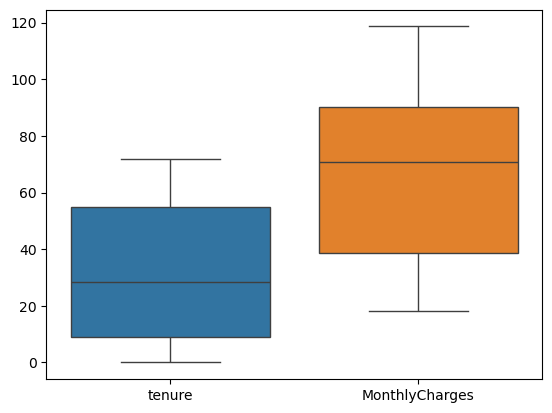

In [11]:
sns.boxplot(df)

In [12]:
# IQR Capping
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))

<Axes: >

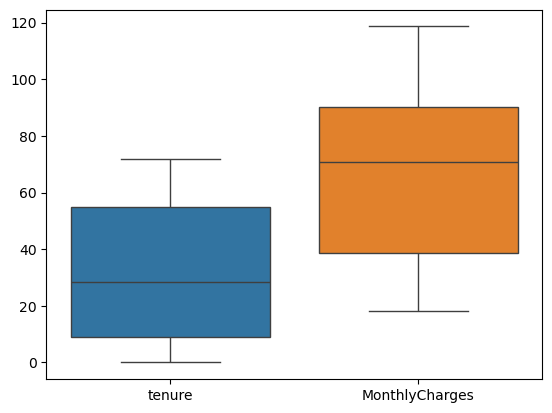

In [13]:
# After capping — re-visualize
sns.boxplot(df)

## Correlation Heatmap

### Objective:
- Identify relationships and multicollinearity between numerical features.

### Insights:
- Total day charge is perfectly correlated with Total day minutes — one can be dropped
- Same pattern exists for evening, night, and international charge/minutes pairs
- Customer service calls shows the strongest correlation with the churn target

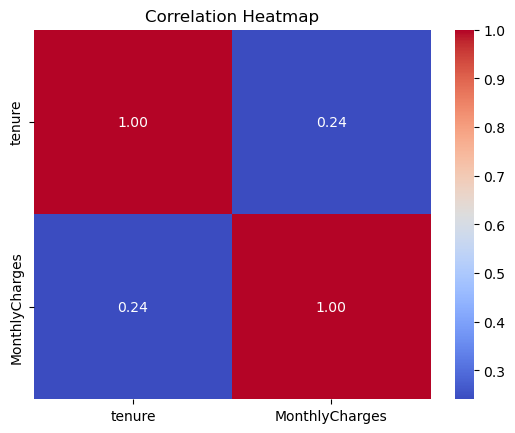

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Categorical Feature vs Churn

### Objective: 
- Analyze how categorical features relate to churn behavior.

### Insights:
- International plan = Yes customers churn at a much higher rate
- Voice mail plan subscribers churn less frequently
- State shows regional variation in churn

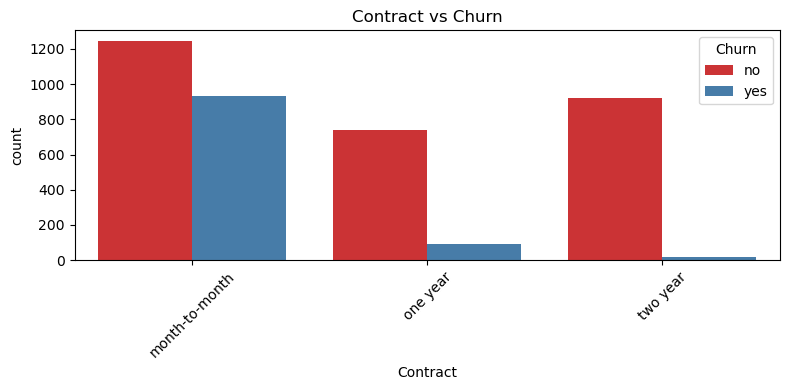

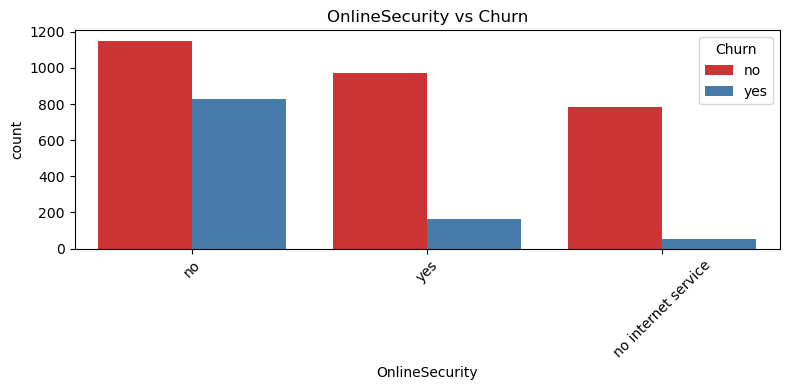

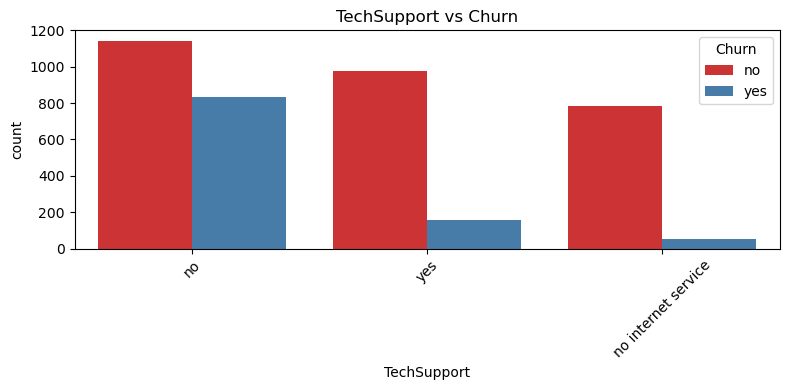

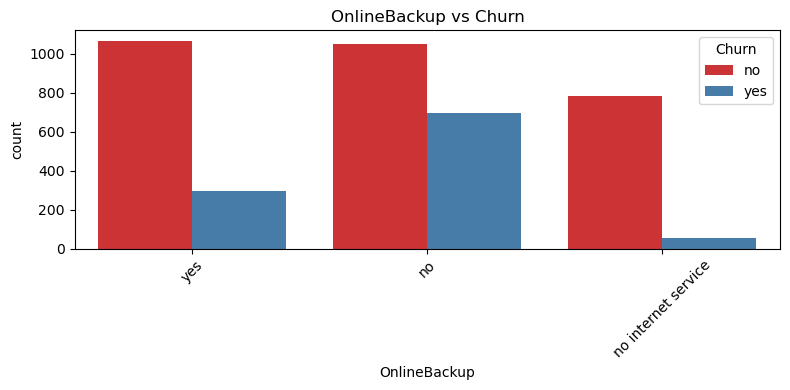

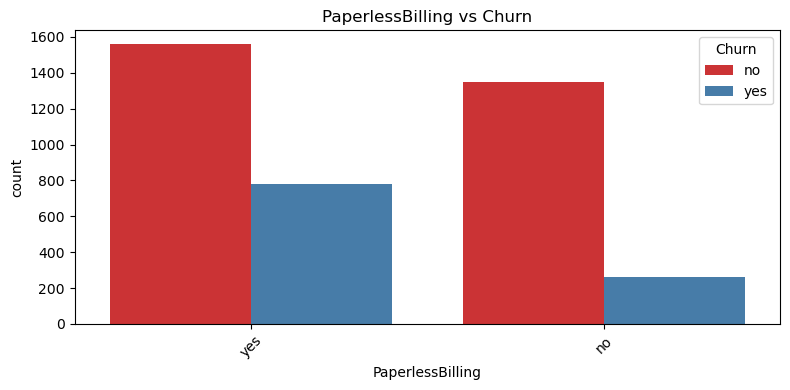

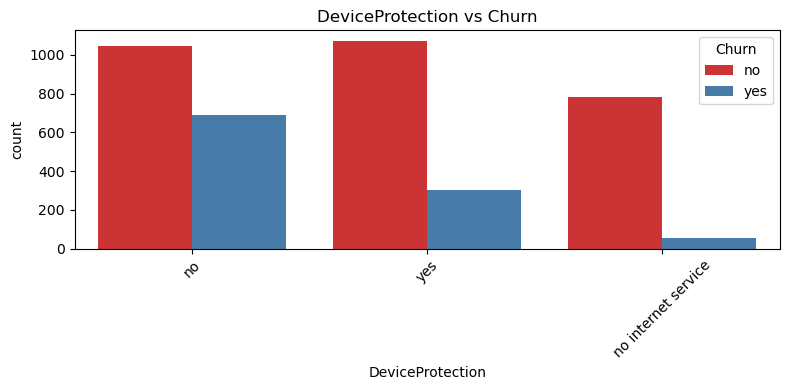

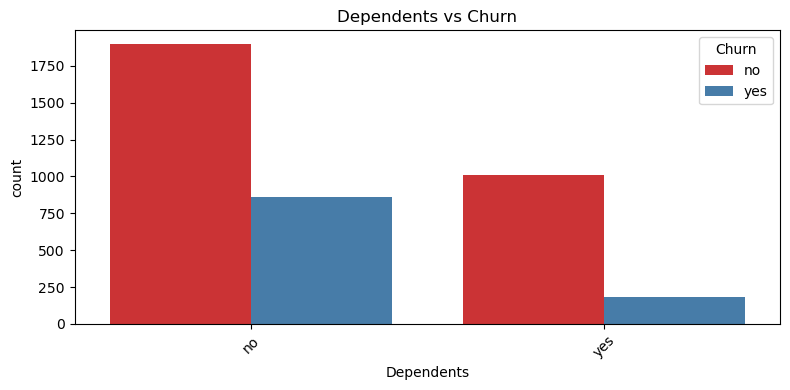

In [15]:
for col in cat_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="Churn", data=df, palette="Set1")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Step 7 — Solving EDA questions on this Dataset

### Objective:
- Understand customer behavior patterns and identify features most strongly associated with churn.

### Insights:
- Customers with more customer service calls have significantly higher churn rates
- International plan subscribers churn more than non-subscribers
- High total day charges correlate with higher churn likelihood
- Churned customers tend to have lower voicemail message counts

### 1. What is the distribution of customer churn?

### Objective
- Understand the proportion of customers who stayed and left.
- Measure the overall churn rate.

### Insights
- Most customers are retained by the company.
- A noticeable number of customers have churned.

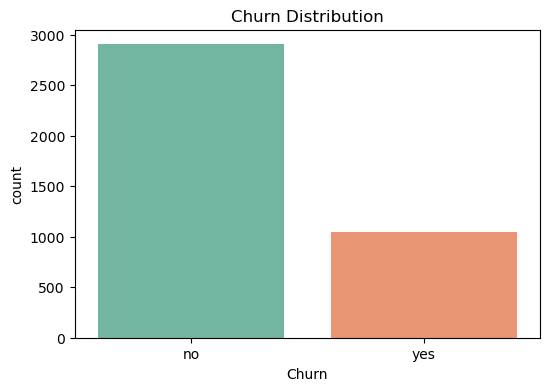

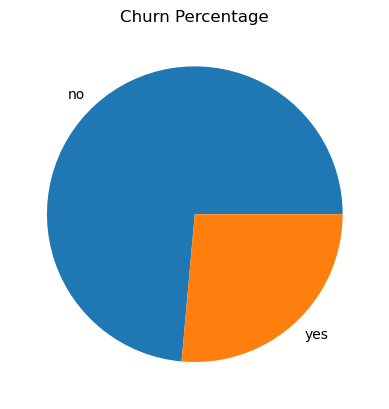

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

### 2. Which contract type has the highest churn?

### Objective
- Identify contract plans with maximum customer loss.
- Help improve retention strategies.

### Insights
- Month-to-month customers have higher churn.
- Long-term contracts retain customers better.

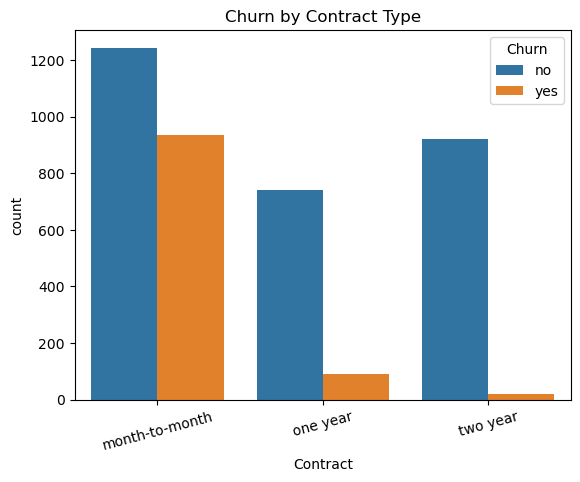

In [17]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Churn by Contract Type')
plt.show()

### 3. Does tenure affect customer churn?

### Objective
- Analyze customer loyalty based on tenure.
- Identify customers with high churn risk.

### Insights
- Customers with shorter tenure churn more.
- Long-term customers are more loyal.

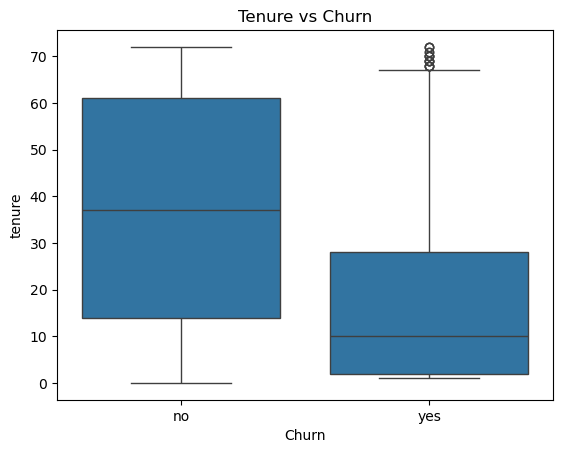

In [18]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

### 4. How do monthly charges influence churn?

### Objective
- Examine the impact of pricing on customer behavior.
- Detect whether higher charges lead to churn.

### Insights
- Customers paying higher monthly charges tend to churn more.
- Competitive pricing can improve retention.

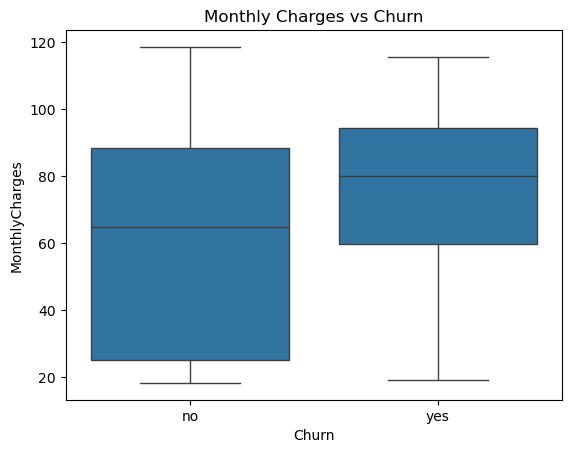

In [19]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

### 5. Does online security reduce churn?

### Objective
- Evaluate the importance of online security services.
- Understand their impact on customer retention.

### Insights
- Customers without online security are more likely to leave.
- Additional services improve customer satisfaction.

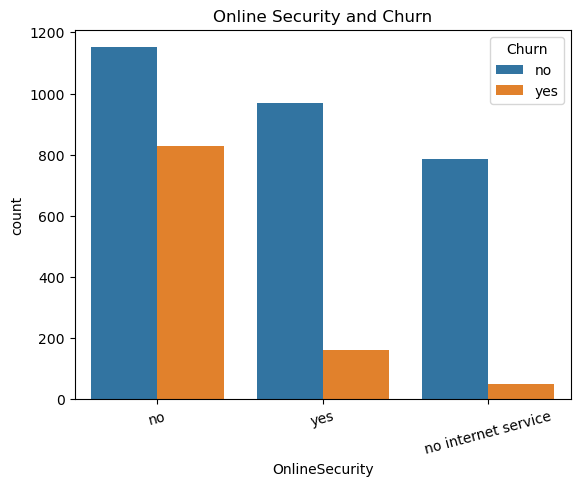

In [20]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Online Security and Churn')
plt.show()

### 6. Does tech support impact churn?

### Objective
- Analyze the importance of customer support.
- Improve service quality and retention.

### Insights
- Customers without tech support churn more.
- Better support increases customer loyalty.

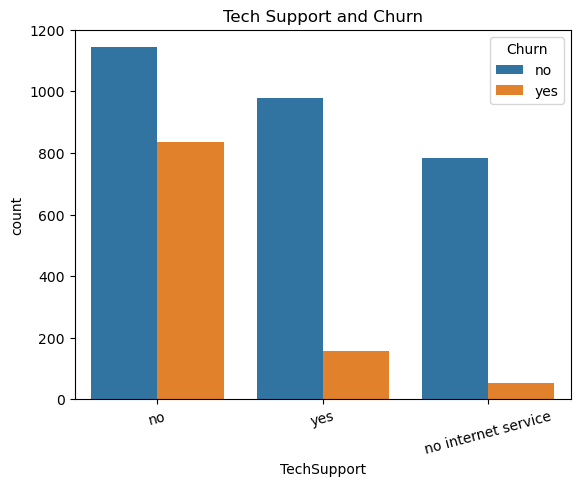

In [21]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Tech Support and Churn')
plt.show()

### 7. How are Total Charges related to customer churn?

### Objective
- Study spending patterns of customers.
- Identify valuable customers at risk of churn.

### Insights
- Customers with lower total charges are more likely to churn.
- Long-term customers generally contribute more revenue.

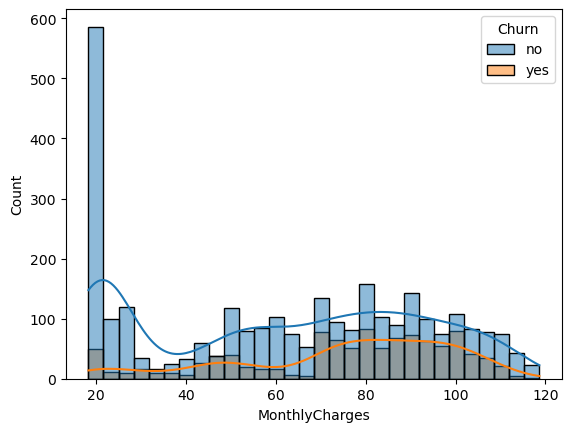

In [22]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.show()

## Final Business Conclusions.

### Major Problems
- High churn among new customers due to low tenure.
- Customers with high monthly charges are more likely to leave.
- Frequent customer service issues are increasing churn.
- Low adoption of value-added services leads to customer loss.
- International plan customers show higher churn rates.

### Major Opportunities
- Improve early customer engagement to reduce churn.
- Optimize pricing and offer personalized plans.
- Enhance customer support and complaint resolution.
- Promote Online Security and Tech Support services to increase retention.
- Use churn prediction models to proactively retain high-risk customers.